In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Iris dataset load karo
iris = load_iris()
X = iris.data        # Features (sepal/petal length & width)
y = iris.target      # Labels (0=Setosa, 1=Versicolor, 2=Virginica)

# DataFrame banao dekhne ke liye
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target_names[y]

print(df.head())
print(df.shape)  # 150 rows, 4 features

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
(150, 5)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # Shuffle ke liye
    shuffle=True
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 120
Testing samples: 30


In [5]:
# K=5 se shuru karo (best practice)
model = KNeighborsClassifier(n_neighbors=5)

# Model ko train karo
model.fit(X_train, y_train)

# Predictions lo
predictions = model.predict(X_test)

print("Model trained successfully! ✅")

Model trained successfully! ✅


F1 Score: 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



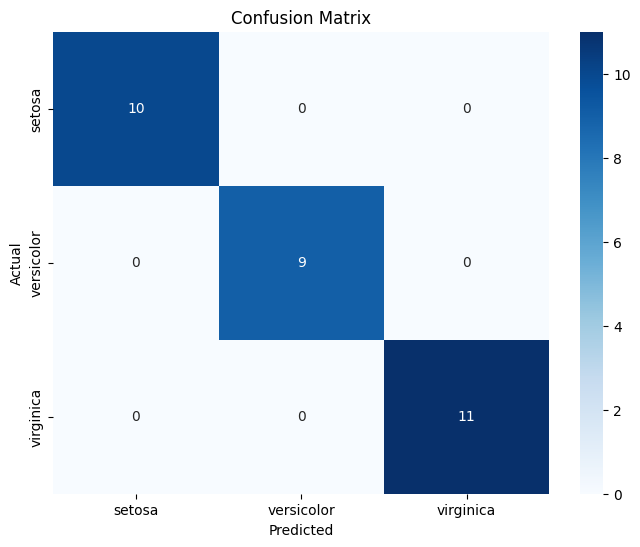

In [6]:
# F1 Score
f1 = f1_score(y_test, predictions, average='weighted')
print(f"F1 Score: {f1:.4f}")

# Full Report
print(classification_report(y_test, predictions,
      target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

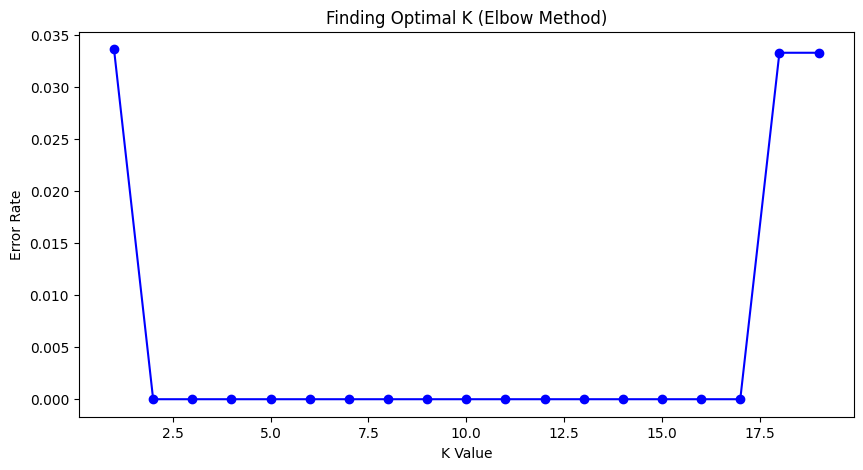

In [9]:
error_rates = []

for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rates.append(1 - f1_score(y_test, pred, average='weighted'))

plt.figure(figsize=(10,5))
plt.plot(range(1,20), error_rates, marker='o', color='blue')
plt.title('Finding Optimal K (Elbow Method)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.savefig('elbow_curve.png')
plt.show()